# Fluke Print detection using YOLO - Exploratory Phase

## Intro

Thermal images downloaded from Roboflow dataset. 

- First model that is going to be tested : YOLOv8-seg (nano)
- What we want : Instance Segmentation - This method treats each object as a unique entity. It detects individual instances and assigns a unique label to the pixels of each one. 
- Then maybe also test this model : YOLO26n-seg

In [1]:
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
import cv2
import numpy as np

### Testing part

In [ ]:
# Load a model

# model = YOLO("yolo26n-seg.pt")  # load an official model

Conversion of the data in the good format (= polygon labels stored in .txt files)

In [ ]:
"""
convert_coco(
    labels_dir="24_02_dataset/train",
    use_segments=True
)
"""

'\nfrom ultralytics.data.converter import convert_coco\n\nconvert_coco(\n    labels_dir="24_02_dataset/train",\n    use_segments=True\n)\n'

Predict with pretrained model (can only detect person, car...) just to test the pipeline

In [9]:
"""
# Predict with the model
results = model.predict(
    source="./coco_converted/images/train",
    save=True,
    conf=0.25
)
"""

'\n# Predict with the model\nresults = model.predict(\n    source="./coco_converted/images/train",\n    save=True,\n    conf=0.25\n)\n'

In [ ]:
"""
folder = "runs/segment/predict"

for file in os.listdir(folder):
    img = cv2.imread(os.path.join(folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
"""

'\nimport os\nimport cv2\nimport matplotlib.pyplot as plt\n\nfolder = "runs/segment/predict"\n\nfor file in os.listdir(folder):\n    img = cv2.imread(os.path.join(folder, file))\n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)\n\n    plt.figure(figsize=(6,6))\n    plt.imshow(img)\n    plt.axis("off")\n'

### First training yolov8n-seg with 17_03_dataset
Pipeline with the complete dataset already in the good format from Roboflow downloading (no need of conversion)

In [ ]:
# repartition of the images in the dataset
dataset_path = "./17_03_dataset"

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_path, split, "images")
    print(split, "images:", len(os.listdir(img_dir)))

train images: 411
valid images: 127
test images: 95


In [ ]:
# download the model
model = YOLO("yolov8n-seg.pt")

In [ ]:
# train the model on our dataset
results = model.train(
    data="./17_03_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    workers=4,
    project="runs_fluke",
    name="yolo_fluke_seg"
)

New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./17_03_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

In [ ]:
# Evaluate on the validation dataset
metrics = model.val(
    data="./17_03_dataset/data.yaml",
    split="test"
)

print(metrics)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 920.0±169.0 MB/s, size: 11.3 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/17_03_dataset/test/labels... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 1.7Kit/s 0.1s
val: New cache created: /home/floreM/FlukePrint_YOLO/17_03_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.4it/s 1.8s0.3s
                   all         95        297      0.822      0.778      0.838       0.62      0.822      0.778      0.838       0.55
Speed: 2.4ms preprocess, 2.5ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/runs/segment/val
ultralytics.utils.metrics.SegmentMetrics object 

In [ ]:
# Predict on the test dataset
predictions = model.predict(
    source="./17_03_dataset/test/images",
    save=True,
    conf=0.25
)


image 1/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 640x640 1 flukeprints, 4.6ms
image 2/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 640x640 1 flukeprints, 4.8ms
image 3/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 640x640 2 flukeprintss, 4.7ms
image 4/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 640x640 2 flukeprintss, 4.6ms
image 5/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 640x640 7 flukeprintss, 4.6ms
image 6/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_510_t-00010s_jpg.rf

### Our model here

In [3]:
# Save best weights
model = YOLO("./runs/segment/runs_fluke/exp_fluke_v1/weights/best.pt")

In [2]:
images_path = "./17_03_dataset/test/images"
labels_path = "./17_03_dataset/test/labels"

image_files = [f for f in os.listdir(images_path) if f.endswith(".jpg")]

In [3]:
def draw_ground_truth(img, label_path):

    h, w, _ = img.shape

    if os.path.exists(label_path):

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            values = list(map(float, line.strip().split()))
            polygon = values[1:]

            polygon = np.array(polygon).reshape(-1,2)

            polygon[:,0] *= w
            polygon[:,1] *= h

            polygon = polygon.astype(np.int32)

            cv2.polylines(img, [polygon], True, (255,0,0), 2)

    return img

### Now we use our trained model

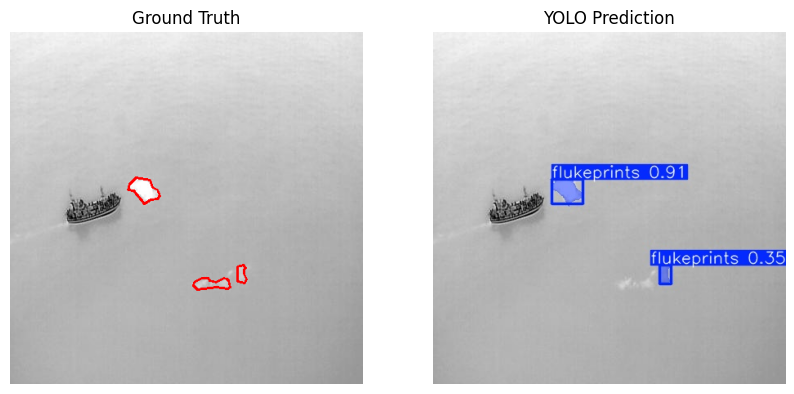

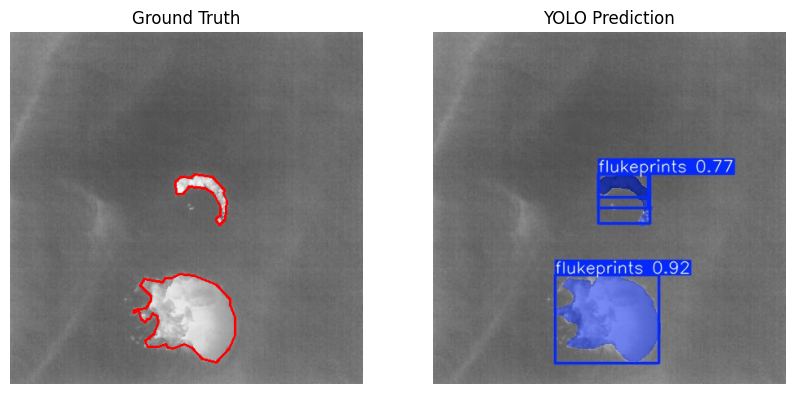

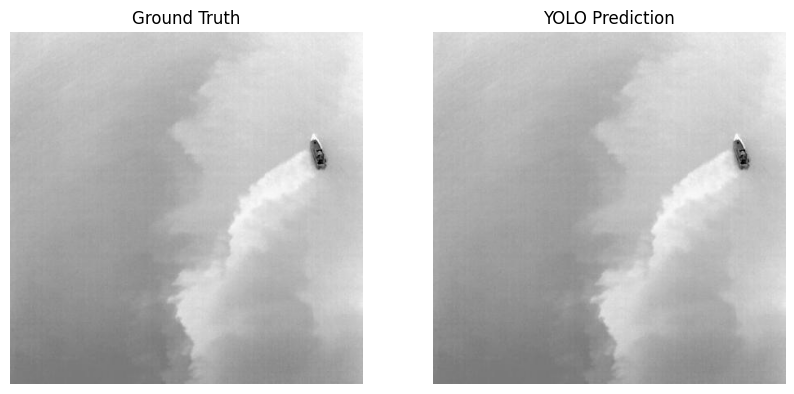

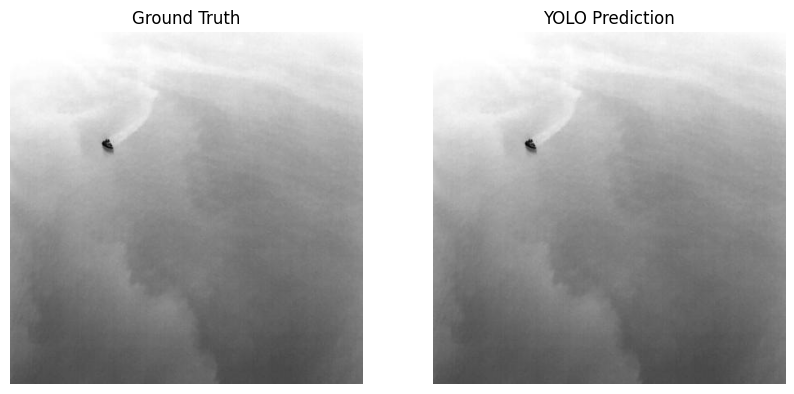

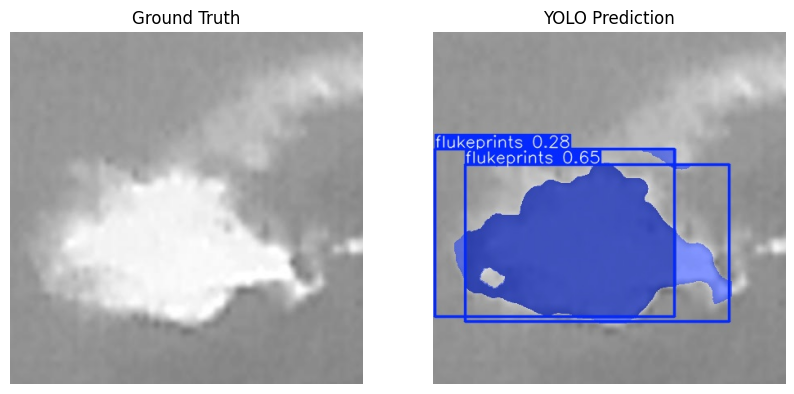

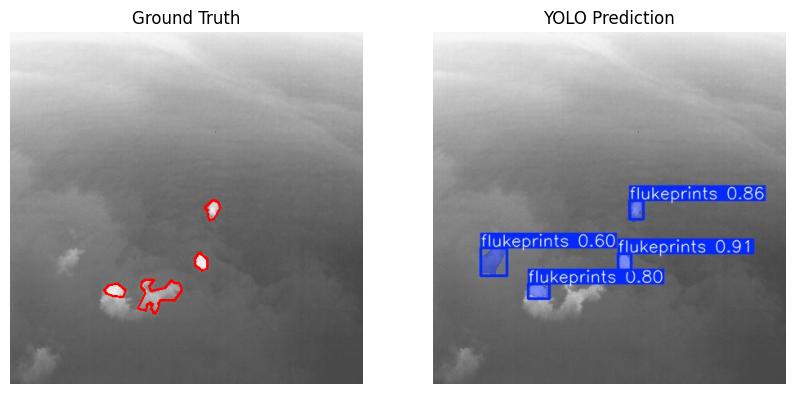

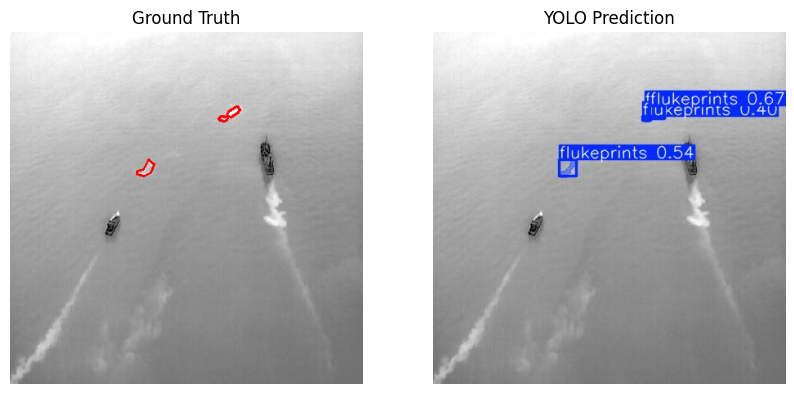

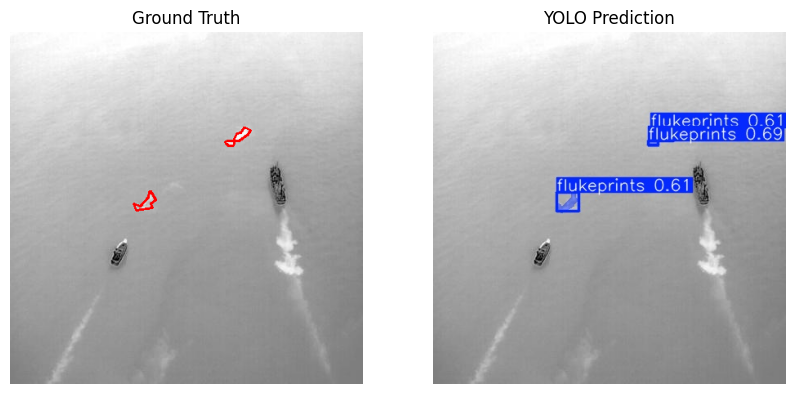

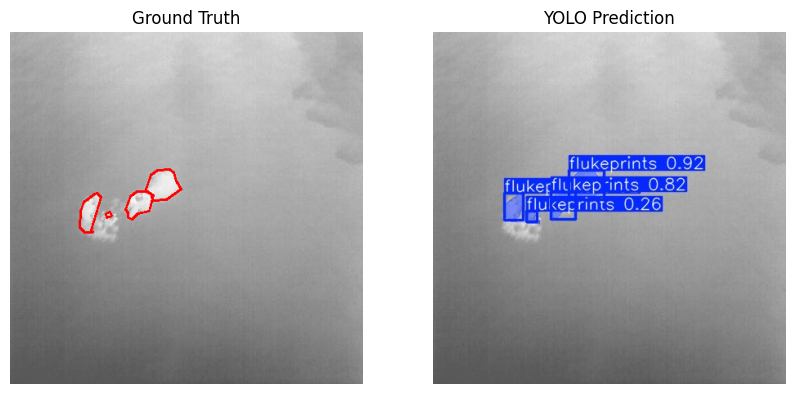

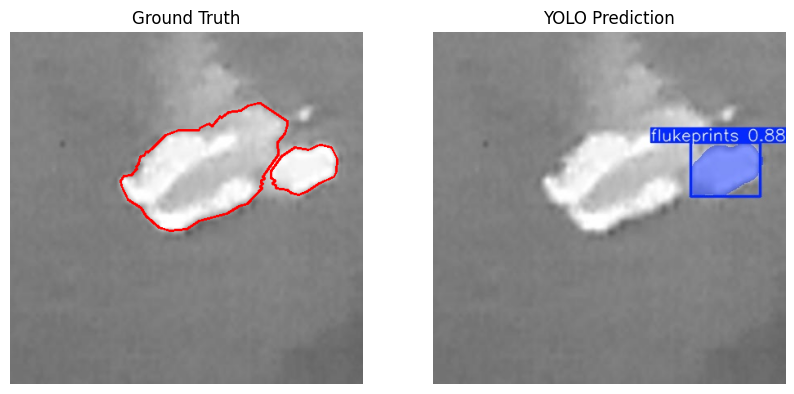

In [ ]:
# Visualizing the predictions on the test set in comparison with the groundtruth

pred_path = "./runs/segment/predict"

pred_files = [f for f in os.listdir(pred_path) if f.endswith(".jpg")]

sample_images = random.sample(pred_files, min(10, len(pred_files)))

for img_name in sample_images:

    # ---------- prediction image ----------
    pred_img_path = os.path.join(pred_path, img_name)
    pred_img = cv2.imread(pred_img_path)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title("YOLO Prediction")
    plt.axis("off")

    plt.show()

#### inspection of the trained model loaded

In [13]:
# neural network architecture
print(model.model)

SegmentationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d

In [ ]:
# nb of parameters = model size
total_params = sum(p.numel() for p in model.model.parameters())
print("Total parameters:", total_params)

Total parameters: 3258259


In [16]:
# print model info summary
model.info()

YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs


(86, 3258259, 0, 11.343974399999999)

In [17]:
# training config 
print(model.args)

{'task': 'segment', 'data': './17_03_dataset/data.yaml', 'imgsz': 640, 'single_cls': False, 'model': './runs/segment/runs_fluke/yolo_fluke_seg/weights/best.pt'}


In [ ]:
# print metrics from validation
metrics = model.val(data="./17_03_dataset/data.yaml")
print(metrics)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 583.6±170.4 MB/s, size: 12.3 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/17_03_dataset/valid/labels.cache... 127 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 22.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.7it/s 2.1s0.4ss
                   all        127        335      0.745      0.764      0.789      0.592      0.746      0.764      0.783      0.534
Speed: 2.8ms preprocess, 2.3ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/runs/segment/val2
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object a

In [19]:
# Predict on the test dataset
predictions = model.predict(
    source="./17_03_dataset/test/images",
    save=True,
    conf=0.25
)
print(predictions)


image 1/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 640x640 1 flukeprints, 5.5ms
image 2/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 640x640 1 flukeprints, 4.8ms
image 3/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 640x640 2 flukeprintss, 4.8ms
image 4/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 640x640 2 flukeprintss, 4.7ms
image 5/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 640x640 7 flukeprintss, 4.8ms
image 6/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_510_t-00010s_jpg.rf

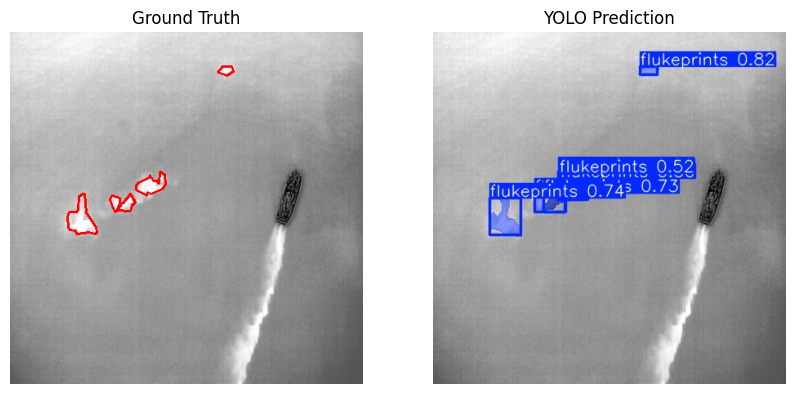

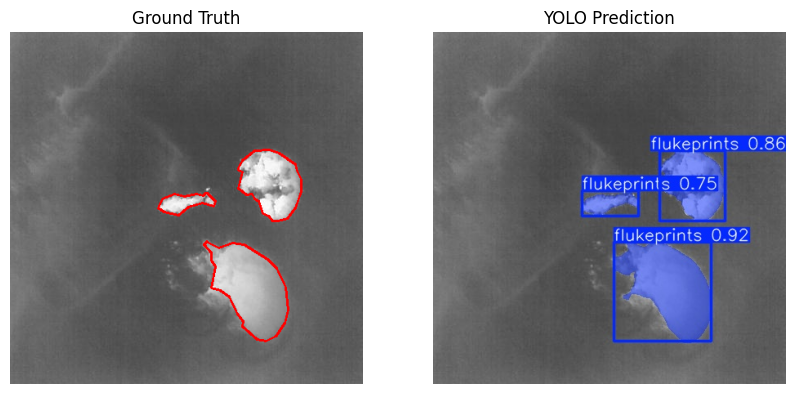

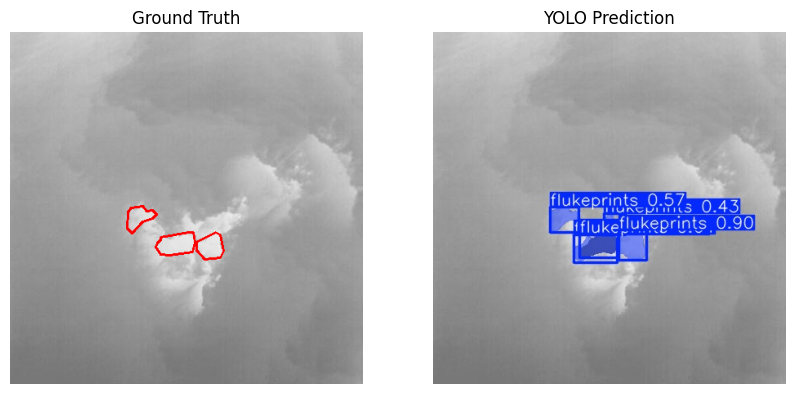

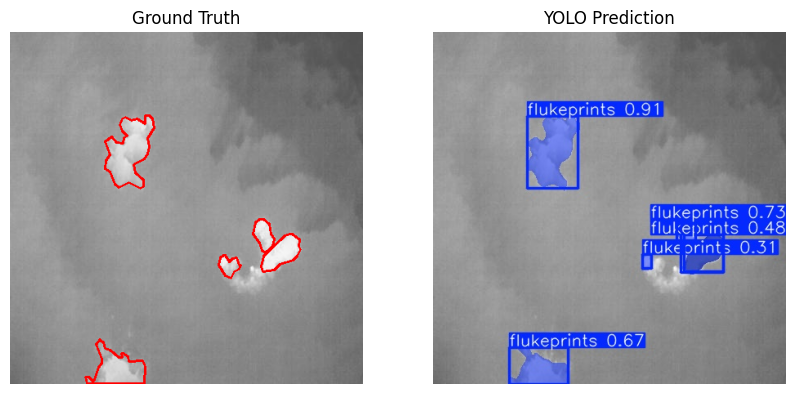

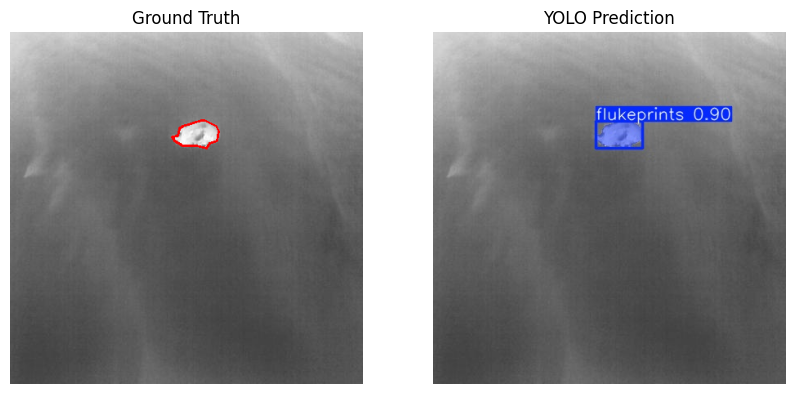

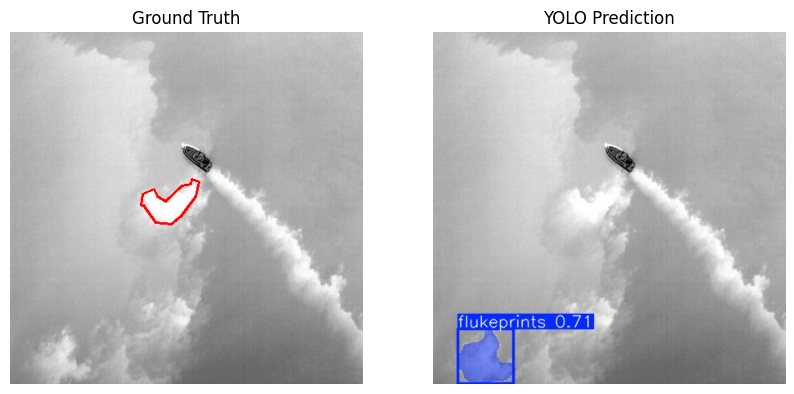

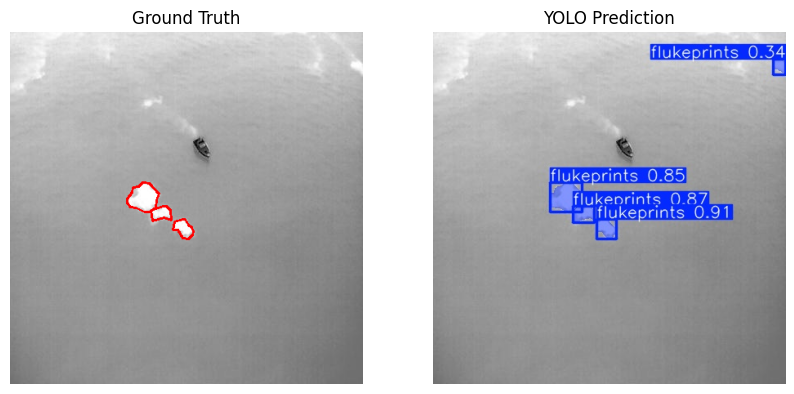

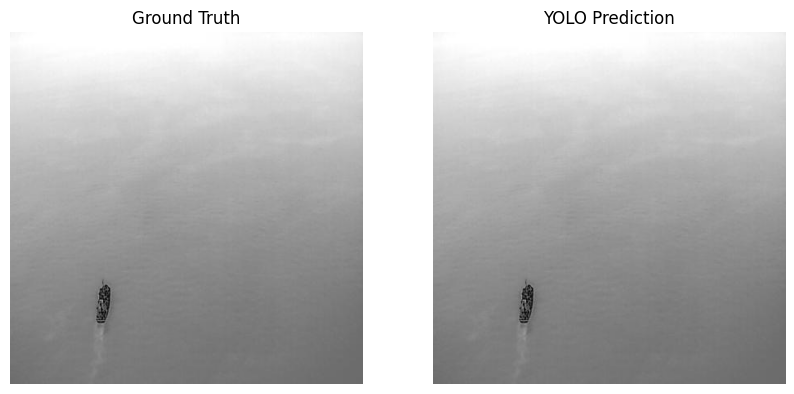

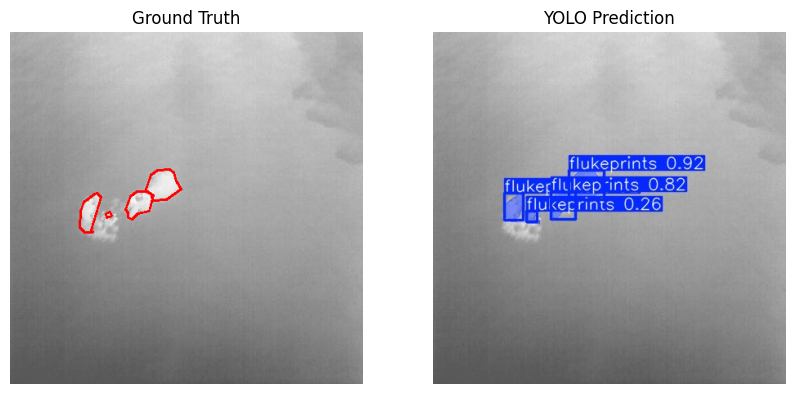

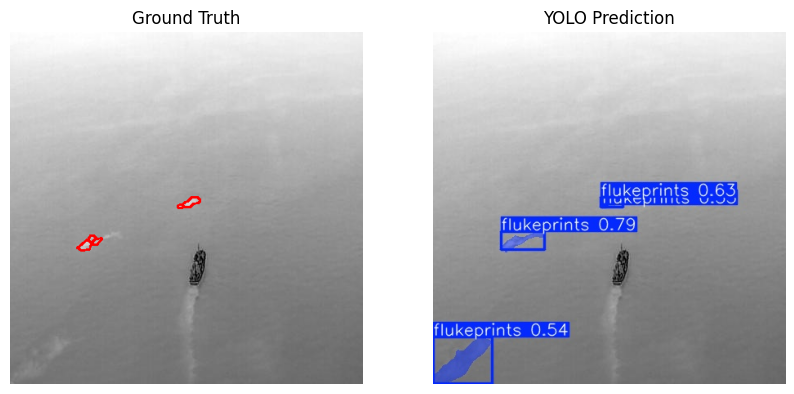

In [11]:
# Visualizing the second predictions on the test set in comparison with the groundtruth

pred_path = "./runs/segment/predict2"

pred_files = [f for f in os.listdir(pred_path) if f.endswith(".jpg")]

sample_images = random.sample(pred_files, min(10, len(pred_files)))

for img_name in sample_images:

    # ---------- prediction image ----------
    pred_img_path = os.path.join(pred_path, img_name)
    pred_img = cv2.imread(pred_img_path)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title("YOLO Prediction")
    plt.axis("off")

    plt.show()

### Think about ameliorations on the predictions

We see that there are some overlap, this can be improved by reducing the value of the iou parameter. It was set by default at 0.7, meaning a toleration of 70% overlap... which seems to hish in our case

In [3]:
# Predict on the test dataset with a lower iou to reduce overlapping predictions
predictions = model.predict(
    source="./17_03_dataset/test/images",
    save=True,
    conf=0.25,
    iou=0.3
)


image 1/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 640x640 1 flukeprints, 4.9ms
image 2/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 640x640 1 flukeprints, 5.2ms
image 3/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 640x640 2 flukeprintss, 4.7ms
image 4/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 640x640 2 flukeprintss, 4.8ms
image 5/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 640x640 7 flukeprintss, 4.6ms
image 6/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_510_t-00010s_jpg.rf

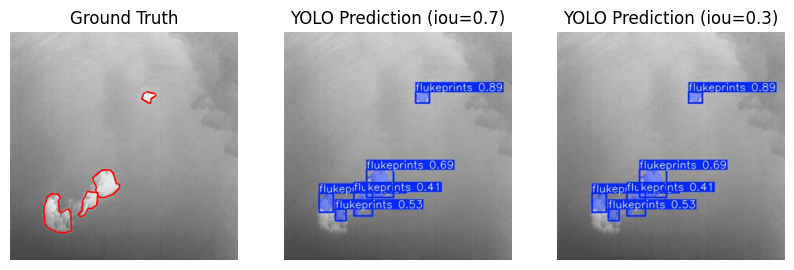

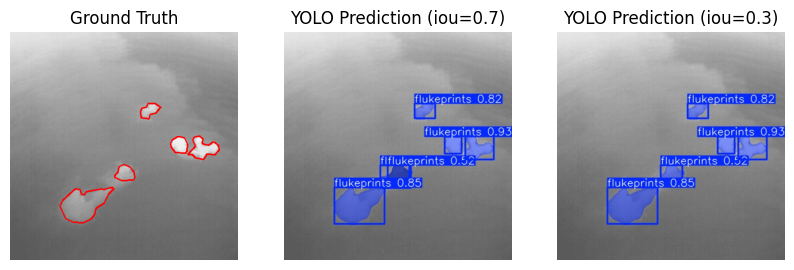

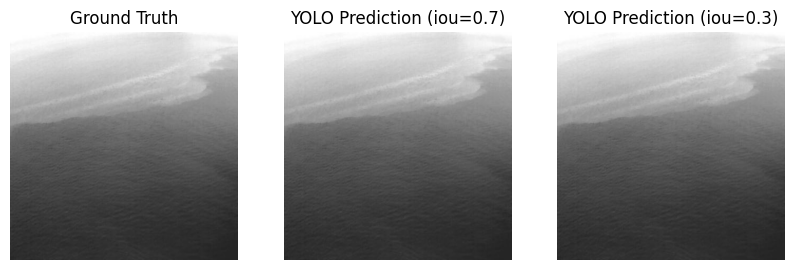

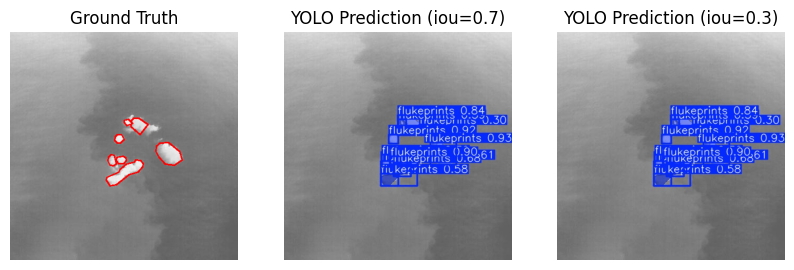

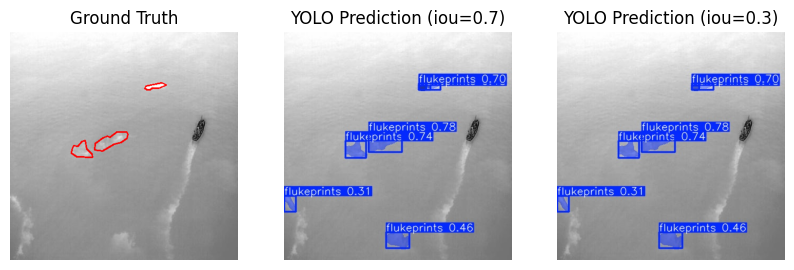

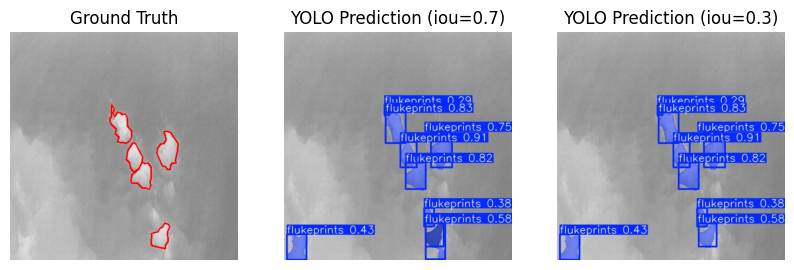

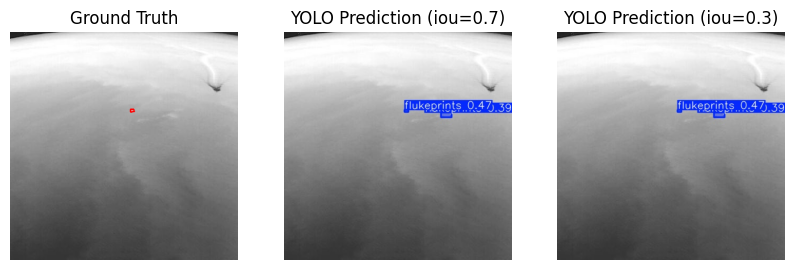

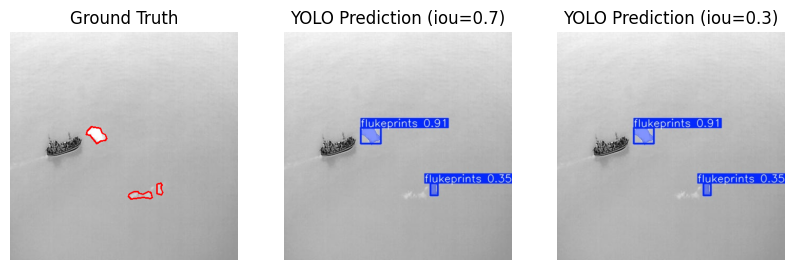

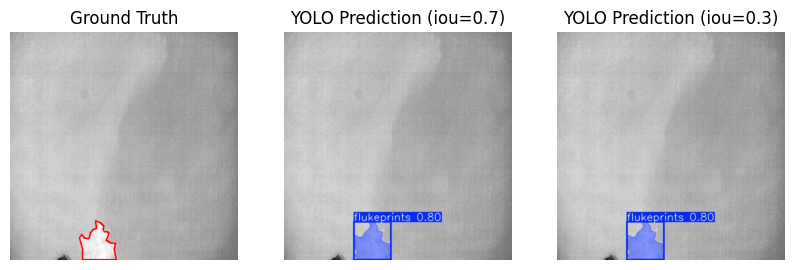

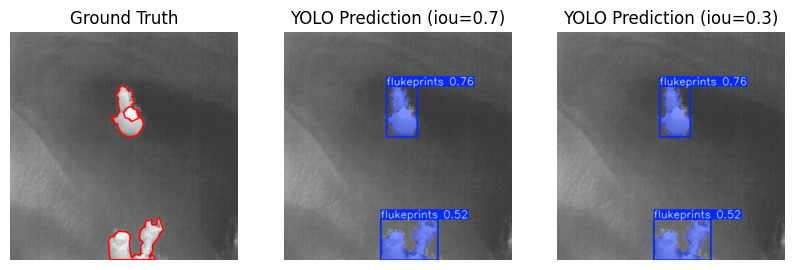

In [ ]:
# Visualizing of this new predictions on the test set - to see if less overlap with iou=0.3 

pred3_path = "./runs/segment/predict_iou0.3"
pred3_files = [f for f in os.listdir(pred3_path) if f.endswith(".jpg")]
sample_images = random.sample(pred3_files, min(10, len(pred3_files)))

predB_path = "./runs/segment/predict_best"

for img_name in sample_images:

    # ---------- prediction iou=0.3 image ----------
    pred3_img_path = os.path.join(pred3_path, img_name)
    pred3_img = cv2.imread(pred3_img_path)
    pred3_img = cv2.cvtColor(pred3_img, cv2.COLOR_BGR2RGB)

    # ---------- prediction iou=0.7 image ----------
    predB_img_path = os.path.join(predB_path, img_name)
    predB_img = cv2.imread(predB_img_path)
    predB_img = cv2.cvtColor(predB_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,3,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(predB_img)
    plt.title("YOLO Prediction (iou=0.7)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred3_img)
    plt.title("YOLO Prediction (iou=0.3)")
    plt.axis("off")

    

    plt.show()

We can see some improvement but not full correction of the problem !

In [6]:
# metrics on the val set with lower confidence threshold to see if we can detect more flukeprints (but with more false positives)
val_conf01 = model.val(
    source="./17_03_dataset/val/images",
    save=True,
    conf=0.10,
    iou=0.3
)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 810.4±229.0 MB/s, size: 12.1 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/17_03_dataset/valid/labels.cache... 127 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 15.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.4it/s 1.8s0.4s
                   all        127        335      0.782      0.758      0.803      0.629      0.782      0.758      0.802      0.573
Speed: 2.7ms preprocess, 1.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/runs/segment/val2


### Second training 

Changes are:
- correct the image size from 640 to the right one 432
- more epoch as the loss functions still decrease : from 50 to 100
- more batch : no
- tune the yolo augmentation : cf fluke_train2.yaml
- model : use yolo26n-seg !
- maybe change the confidence threshold : 

==> these new param are written in a file fluke_train2.yaml for simplicity, repetability 


In [10]:
model = YOLO("yolo26n-seg.pt") 

results = model.train(cfg="./17_03_dataset/fluke_train2.yaml")

New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=./17_03_dataset/fluke_train2.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./17_03_dataset/data.yaml, degrees=360.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=432, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

In [11]:
metrics_val = model.val(source="./17_03_dataset/data.yaml", save=True, iou=0.3)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 802.9±150.0 MB/s, size: 10.0 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/17_03_dataset/valid/labels.cache... 127 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 44.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.6it/s 1.7s0.4s
                   all        127        335      0.693      0.701      0.726      0.521      0.712      0.699      0.731      0.454
Speed: 1.4ms preprocess, 2.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/runs/segment/val2


In [12]:
predictions = model.predict(
    source="./17_03_dataset/test/images",
    save=True,
    conf=0.25,
    iou=0.3
)


image 1/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 448x448 (no detections), 6.5ms
image 2/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 448x448 (no detections), 6.8ms
image 3/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 448x448 1 flukeprints, 6.8ms
image 4/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 448x448 1 flukeprints, 7.3ms
image 5/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 448x448 5 flukeprintss, 6.9ms
image 6/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_510_t-00010s_jpg.

### for the second training obtain comparable results

In [4]:
model = YOLO("./runs/segment/train2/weights/best.pt")

In [3]:
metrics_val_best = model.val(source="./17_03_dataset/data.yaml", save=True)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 886.6±244.2 MB/s, size: 11.9 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/17_03_dataset/valid/labels.cache... 127 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 17.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.5it/s 1.8s0.2s
                   all        127        335      0.693      0.701      0.726      0.521      0.712      0.699      0.731      0.454
Speed: 1.4ms preprocess, 2.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/runs/segment/val4


In [4]:
predictions2_best = model.predict(
    source="./17_03_dataset/test/images",
    save=True
)


image 1/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 448x448 (no detections), 7.2ms
image 2/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 448x448 (no detections), 7.3ms
image 3/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 448x448 1 flukeprints, 7.2ms
image 4/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 448x448 1 flukeprints, 7.6ms
image 5/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 448x448 5 flukeprintss, 8.4ms
image 6/95 /home/floreM/FlukePrint_YOLO/17_03_dataset/test/images/video_030_event10_A018_510_t-00010s_jpg.

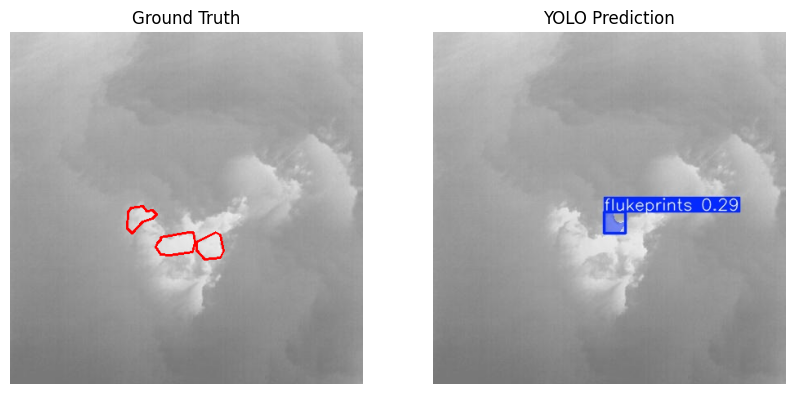

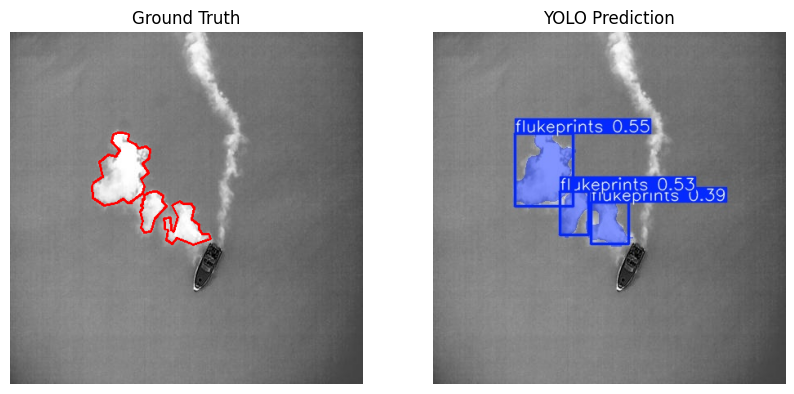

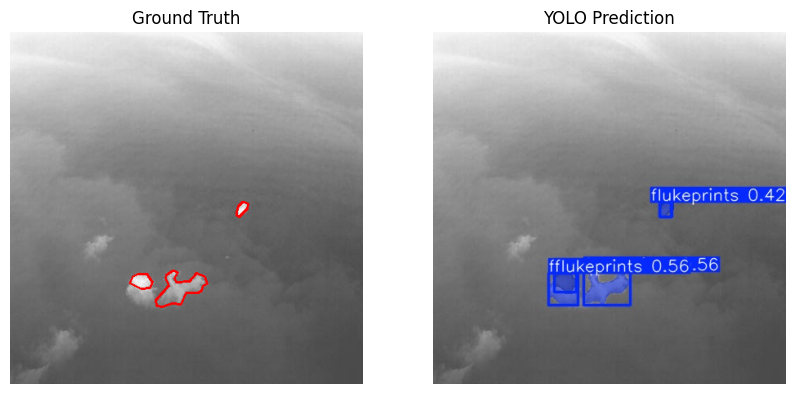

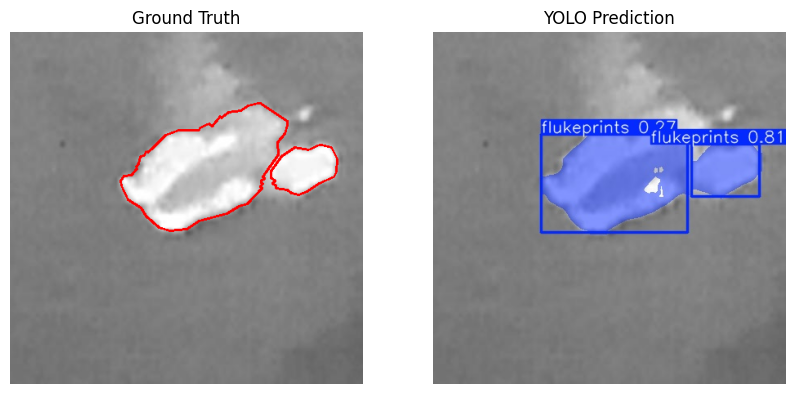

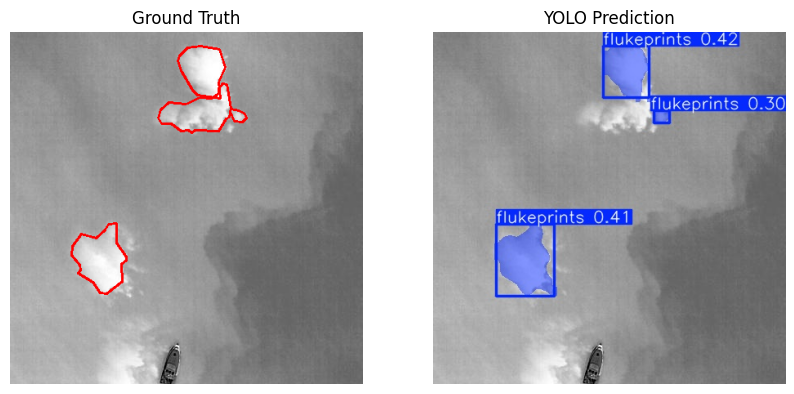

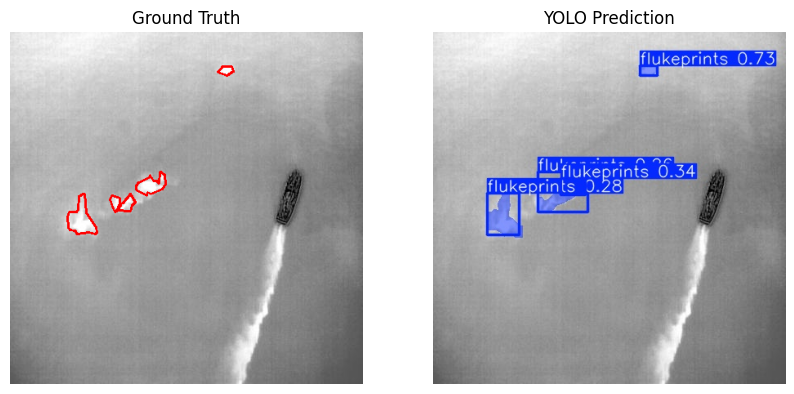

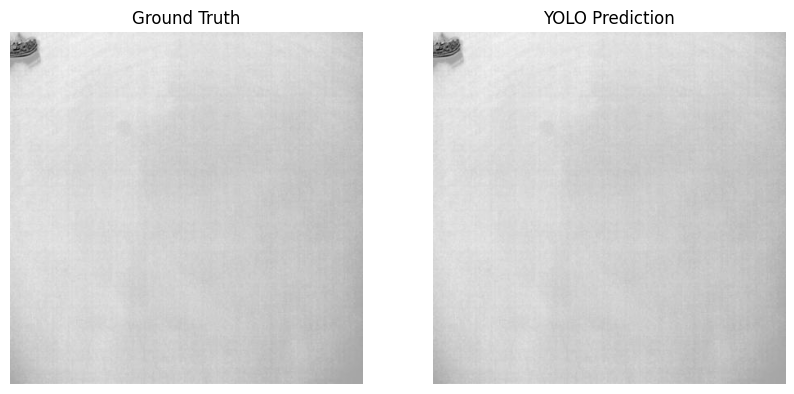

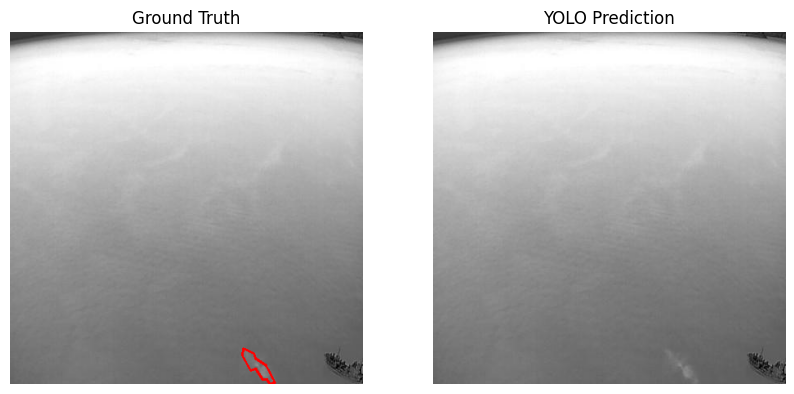

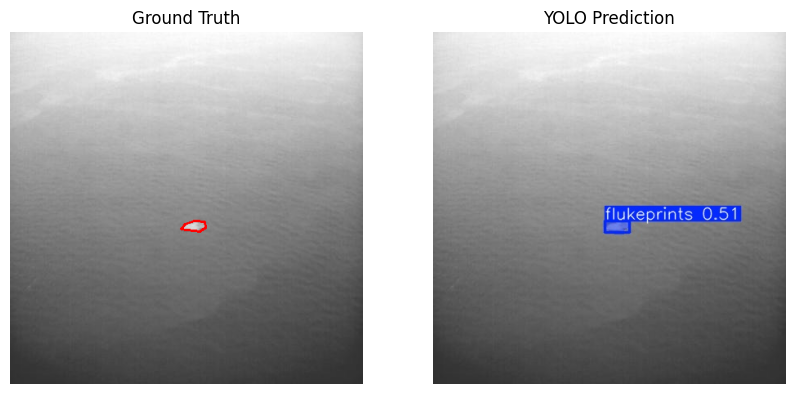

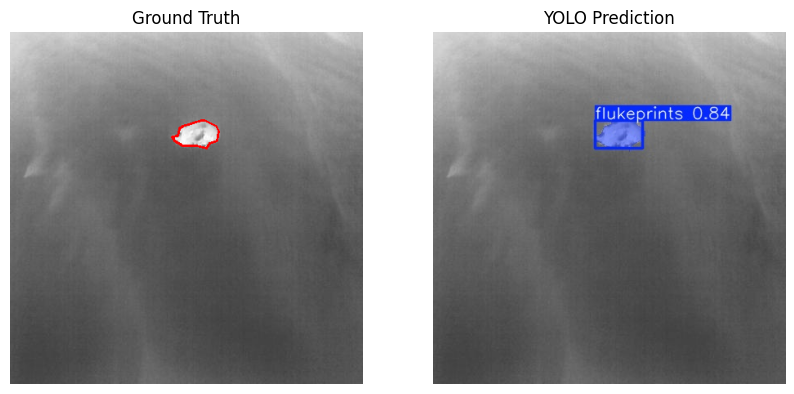

In [5]:
# Visualizing the predictions on the test set in comparison with the groundtruth

pred_path = "./runs/segment/predict2_best"

pred_files = [f for f in os.listdir(pred_path) if f.endswith(".jpg")]

sample_images = random.sample(pred_files, min(10, len(pred_files)))

for img_name in sample_images:

    # ---------- prediction image ----------
    pred_img_path = os.path.join(pred_path, img_name)
    pred_img = cv2.imread(pred_img_path)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title("YOLO Prediction")
    plt.axis("off")

    plt.show()

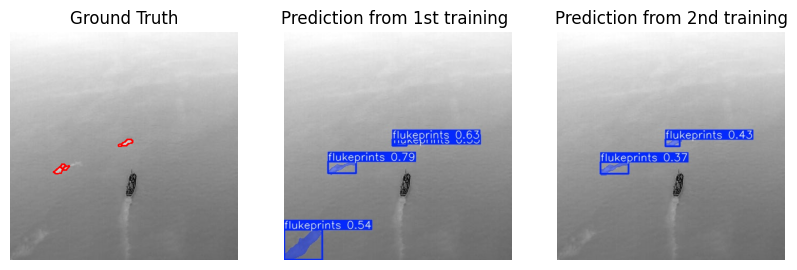

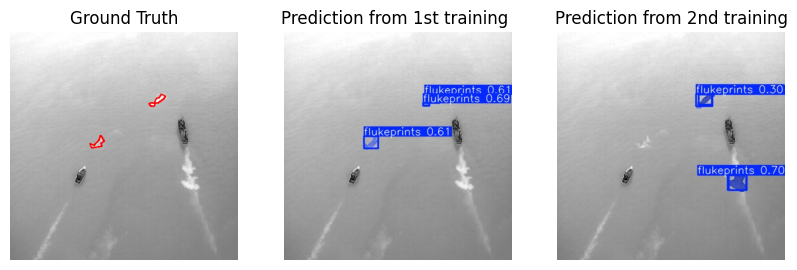

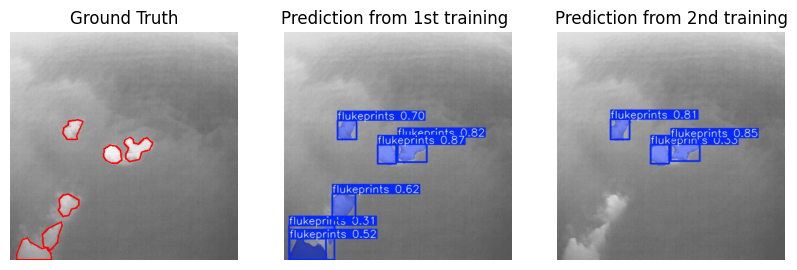

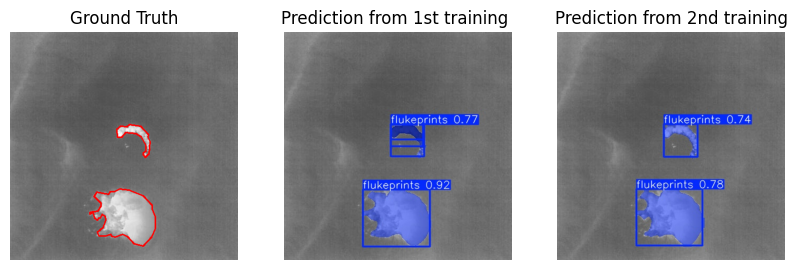

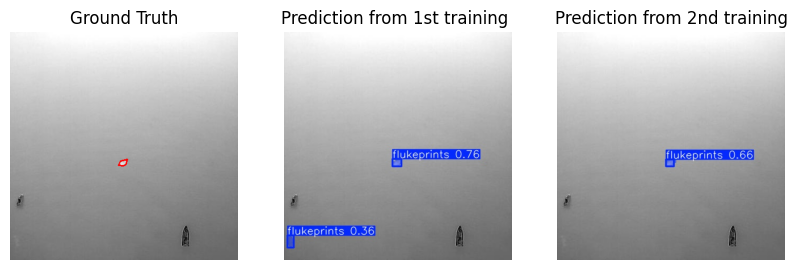

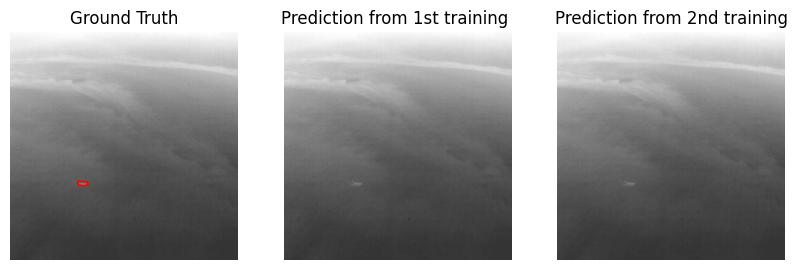

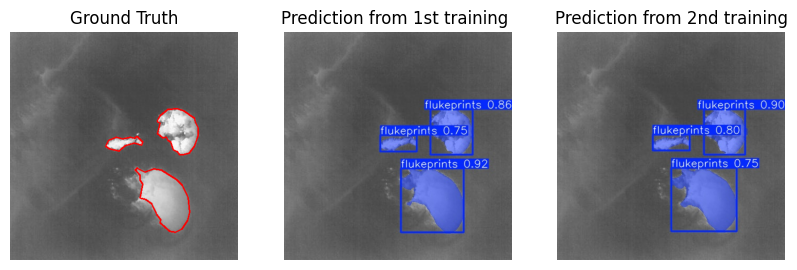

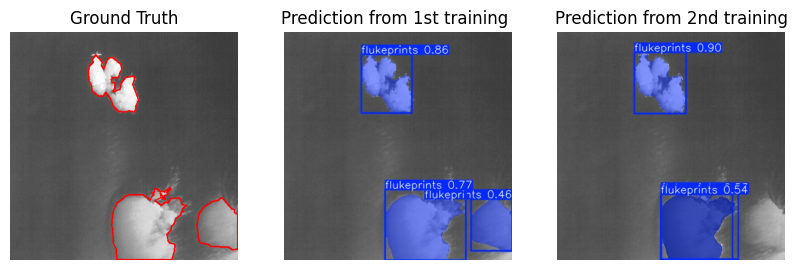

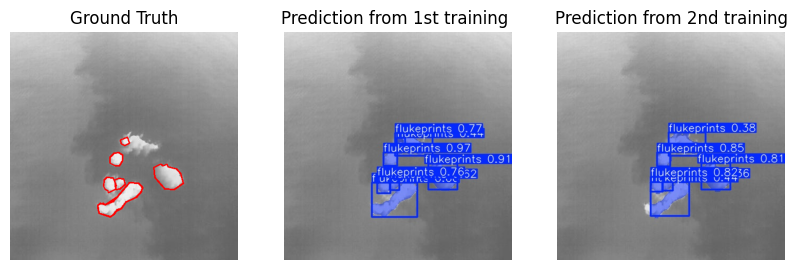

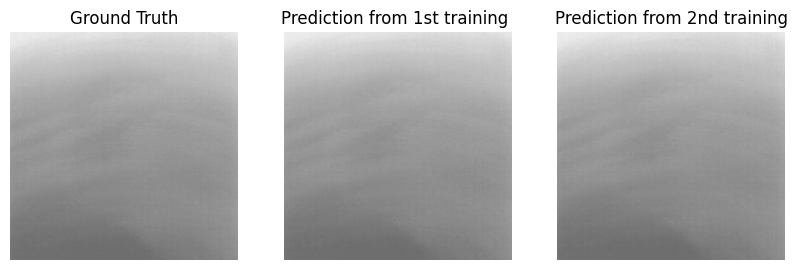

In [8]:
# Visualizing of this new predictions on the test set - to see if less overlap with iou=0.3 

pred2_path = "./runs/segment/predict2_best"
pred2_files = [f for f in os.listdir(pred2_path) if f.endswith(".jpg")]
sample_images = random.sample(pred2_files, min(10, len(pred2_files)))

pred1_path = "./runs/segment/predict_best"

for img_name in sample_images:

    # ---------- prediction 2 ----------
    pred2_img_path = os.path.join(pred2_path, img_name)
    pred2_img = cv2.imread(pred2_img_path)
    pred2_img = cv2.cvtColor(pred2_img, cv2.COLOR_BGR2RGB)

    # ---------- prediction 1 ----------
    pred1_img_path = os.path.join(pred1_path, img_name)
    pred1_img = cv2.imread(pred1_img_path)
    pred1_img = cv2.cvtColor(pred1_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,3,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(pred1_img)
    plt.title("Prediction from 1st training ")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred2_img)
    plt.title("Prediction from 2nd training")
    plt.axis("off")

    

    plt.show()